In [1]:
!pip -q install git+https://github.com/openai/CLIP.git
!pip -q install ftfy regex tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 632.5 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 50.1 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you

In [3]:
import torch 
import torch.nn.functional as F
import clip
import matplotlib.pyplot as plt
from PIL import Image 

In [5]:
def show_image(img):

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

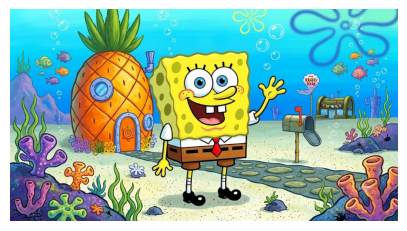

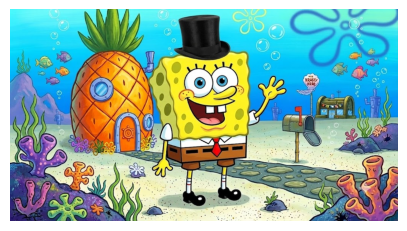

In [7]:
img1 = Image.open("/kaggle/input/datasets/alanfrancis6209/images01/bob01.jpg").convert("RGB")
img2 = Image.open("/kaggle/input/datasets/alanfrancis6209/images01/bob02.jpg").convert("RGB")

show_image(img1)
show_image(img2)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load(
    "ViT-B/32",
    device=device
)
model.eval()

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 217MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [11]:
#preprocessing 

img1 = preprocess(img1).unsqueeze(0).to(device)
img2 = preprocess(img2).unsqueeze(0).to(device)

with torch.no_grad():

    emb1 = model.encode_image(img1).float()
    emb2 = model.encode_image(img2).float()
print(emb1.shape)

torch.Size([1, 512])


In [13]:
emb1 = F.normalize(emb1, p=2, dim=-1)
emb2 = F.normalize(emb2, p=2, dim=-1)

print("Norm Image1:", torch.linalg.norm(emb1, dim=-1))
print("Norm Image1:", torch.linalg.norm(emb2, dim=-1))


Norm Image1: tensor([1.], device='cuda:0')
Norm Image1: tensor([1.], device='cuda:0')


In [16]:
delta = emb2 - emb1
delta = F.normalize( delta, p=2, dim=-1)

In [17]:
words = [
    "hat",
    "cup",
    "cat",
    "boat"
]

with torch.no_grad():

    tokens = clip.tokenize(words).to(device)
    text_emb = model.encode_text(tokens).float()

text_emb = F.normalize(text_emb, p=2, dim=-1)

similarity = delta @ text_emb.T
print(similarity )

tensor([[ 0.1419,  0.0096, -0.0252, -0.0490]], device='cuda:0')


In [19]:
logit_scale = 10.0
logits = similarity * logit_scale

prob = F.softmax(
    logits,
    dim=-1
)

In [21]:

for word, sim, prob in sorted(
    zip(
        words,
        similarity.squeeze().cpu().tolist(),
        prob.squeeze().cpu().tolist()
    ),
    key=lambda x: x[2],
    reverse=True
):

    print(
        f"{word:>5s} | "
        f"Cosine = {sim:+.4f} | "
        f"Probability = {prob:.4f}"
    )

  hat | Cosine = +0.1419 | Probability = 0.6239
  cup | Cosine = +0.0096 | Probability = 0.1662
  cat | Cosine = -0.0252 | Probability = 0.1174
 boat | Cosine = -0.0490 | Probability = 0.0925
